<a href="https://colab.research.google.com/github/Ashishmthaha/Driver-Behaviour-Analysis-And-Collision-Risk-Warning-System-For-Kerala-Road-Conditions/blob/main/Main%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
#  LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
from google.colab import files
import warnings
warnings.filterwarnings('ignore')


print("="*70)
print(" KULATHOOR FCD → CSV  |  CALIBRATED NOISE  |  V6 FINAL")
print("="*70)



# ============================================================================
#  UPLOAD FCD
# ============================================================================
print(" Upload kulathoor_fcd.xml:")
uploaded = files.upload()
fcd_file = list(uploaded.keys())[0]
print(f" Uploaded: {fcd_file}")


# ============================================================================
# STEP 1: PARSE RAW FCD
# ============================================================================
def parse_fcd(fcd_file):
    tree = ET.parse(fcd_file)
    root = tree.getroot()
    records = []
    for ts in root.findall('timestep'):
        t = float(ts.get('time', 0))
        for v in ts.findall('vehicle'):
            try:
                records.append({
                    'timestamp'   : t,
                    'vehicle_id'  : v.get('id', ''),
                    'vehicle_type': v.get('type', 'unknown'),
                    'speed_ms'    : float(v.get('speed', 0) or 0),
                    'angle'       : float(v.get('angle', 0) or 0),
                    'lane'        : v.get('lane', ''),
                    'pos'         : float(v.get('pos',   0) or 0),
                    'x'           : float(v.get('x',     0) or 0),
                    'y'           : float(v.get('y',     0) or 0),
                    'slope'       : float(v.get('slope', 0) or 0),
                })
            except:
                continue
    df = pd.DataFrame(records)
    print(f" Parsed {len(df)} raw FCD records")
    return df


df_raw = parse_fcd(fcd_file)


# ============================================================================
# STEP 2: VEHICLE TYPE NORMALISATION
# ============================================================================
vmap = {
    # Two-wheelers (tw_*)
    'tw_aggressive': 'twowheeler',
    'tw_normal':     'twowheeler',
    'tw_harsh':      'twowheeler',
    'tw_cautious':   'twowheeler',

    # Cars (car_*)
    'car_normal':    'car',
    'car_aggressive':'car',
    'car_harsh':     'car',

    # Autos
    'auto_normal':   'auto',
    'auto_aggressive':'auto',

    # Buses
    'bus_normal':    'bus',
    'bus_aggressive':'bus',

    # Trucks
    'truck_normal':  'truck',
    'truck_aggressive':'truck',

    # Mini-trucks
    'minitruck_normal': 'minitruck',

    # Cycles
    'cycle_normal':  'cycle',

    # Legacy/simple names (kept for safety)
    'twowheeler':    'twowheeler',
    'motorcycle':    'twowheeler',
    'car':           'car',
    'auto':          'auto',
    'bus':           'bus',
    'truck':         'truck',
    'cycle':         'cycle',
}

df_raw['vehicle_type'] = df_raw['vehicle_type'].map(vmap).fillna('unknown')


# ============================================================================
# STEP 3: PER-VEHICLE TEMPORAL FEATURES
# ============================================================================
df = df_raw.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)

df['acceleration_ms2']   = 0.0
df['heading_change_deg'] = 0.0
df['lane_change']        = 0

for vid, grp in df.groupby('vehicle_id'):
    idx    = grp.index
    speeds = grp['speed_ms'].values
    times  = grp['timestamp'].values
    angles = grp['angle'].values
    lanes  = grp['lane'].values

    dt = np.diff(times)
    dt[dt == 0] = 1.0
    accel = np.diff(speeds) / dt
    df.loc[idx, 'acceleration_ms2'] = np.concatenate([[0.0], accel])

    d_angle = np.diff(angles)
    d_angle = (d_angle + 180) % 360 - 180
    df.loc[idx, 'heading_change_deg'] = np.concatenate([[0.0], d_angle])

    lc = (lanes[1:] != lanes[:-1]).astype(int)
    df.loc[idx, 'lane_change'] = np.concatenate([[0], lc])

df['acceleration_ms2']   = df['acceleration_ms2'].round(3)
df['heading_change_deg'] = df['heading_change_deg'].round(2)
df['speed_kmph']         = (df['speed_ms'] * 3.6).round(2)


# ============================================================================
# STEP 4: PER-TIMESTEP SPATIAL FEATURES (same-lane)
# ============================================================================
df['gap_to_leader_m']     = 999.0
df['relative_speed_kmph'] = 0.0

for ts_val, grp_ts in df.groupby('timestamp'):
    for lane, grp_lane in grp_ts.groupby('lane'):
        if lane == '' or len(grp_lane) < 2:
            continue
        sorted_v  = grp_lane.sort_values('pos')
        positions = sorted_v['pos'].values
        speeds    = sorted_v['speed_ms'].values
        indices   = sorted_v.index
        for i in range(len(indices) - 1):
            follower_idx = indices[i]
            gap          = max(0.5, positions[i + 1] - positions[i])
            rel_speed_ms = speeds[i] - speeds[i + 1]
            df.loc[follower_idx, 'gap_to_leader_m']     = round(gap, 2)
            df.loc[follower_idx, 'relative_speed_kmph'] = round(rel_speed_ms * 3.6, 2)


# ============================================================================
# STEP 5: ENHANCED PET (three radii: 3m / 6m / 10m)
# ============================================================================
print("\n  Computing Enhanced PET...")

PET_SENTINEL   = 999.0
CONFLICT_RADII = [3.0, 6.0, 10.0]

def build_trajectories(df):
    return (df.groupby('vehicle_id')[['timestamp', 'x', 'y']]
              .apply(lambda g: g.sort_values('timestamp').values.tolist())
              .to_dict())

def compute_pet_for_radius(traj, r):
    def cell_key(x, y):
        return (round(x / r) * r, round(y / r) * r)

    cell_occupancy = defaultdict(list)
    for vid, records in traj.items():
        prev_ck = None
        entry_t = None
        for rec in records:
            t, x, y = rec[0], rec[1], rec[2]
            ck = cell_key(x, y)
            if ck != prev_ck:
                if prev_ck is not None and entry_t is not None:
                    cell_occupancy[prev_ck].append((vid, entry_t, t))
                entry_t = t
                prev_ck = ck
        if prev_ck is not None and entry_t is not None:
            cell_occupancy[prev_ck].append((vid, entry_t, records[-1][0]))

    vid_cell_pet = defaultdict(lambda: PET_SENTINEL)
    for ck, occupants in cell_occupancy.items():
        if len(occupants) < 2:
            continue
        occ_sorted = sorted(occupants, key=lambda o: o[1])
        for i in range(len(occ_sorted)):
            vid_a, _, t_exit_a = occ_sorted[i]
            for j in range(i + 1, len(occ_sorted)):
                vid_b, t_enter_b, _ = occ_sorted[j]
                if vid_a == vid_b:
                    continue
                if t_enter_b > t_exit_a:
                    pet = t_enter_b - t_exit_a
                    if 0 < pet < PET_SENTINEL:
                        vid_cell_pet[(vid_a, ck)] = min(vid_cell_pet[(vid_a, ck)], pet)
                        vid_cell_pet[(vid_b, ck)] = min(vid_cell_pet[(vid_b, ck)], pet)
    return vid_cell_pet, cell_key

traj = build_trajectories(df)
df['pet_s'] = PET_SENTINEL

for r in CONFLICT_RADII:
    print(f"   Radius {r}m...")
    vid_cell_pet_r, cell_key_fn = compute_pet_for_radius(traj, r)
    for idx, row in df.iterrows():
        ck  = cell_key_fn(row['x'], row['y'])
        key = (row['vehicle_id'], ck)
        if key in vid_cell_pet_r:
            df.at[idx, 'pet_s'] = min(df.at[idx, 'pet_s'],
                                       round(vid_cell_pet_r[key], 3))

df['pet_s'] = df['pet_s'].round(3)
print(f"\n PET (clean):")
print(f"   Real PET: {(df['pet_s']<999).sum()} / {len(df)} = {(df['pet_s']<999).mean()*100:.1f}%")
print(f"   PET < 1.5s: {(df['pet_s']<1.5).sum()}")
print(f"   PET < 3.0s: {(df['pet_s']<3.0).sum()}")


# ============================================================================
# STEP 6: BINARY FLAGS (from clean features — before noise)
# ============================================================================
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)
# NOTE: wrong_way excluded — SUMO enforces correct-direction routing by design;
#       vehicles cannot travel against traffic in a standard SUMO network.


# ============================================================================
# STEP 7: LABEL FROM CLEAN FEATURES (fixed — never changes)
# ============================================================================
def compute_risk_score(row):
    speed   = row['speed_kmph']
    accel   = row['acceleration_ms2']
    gap     = row['gap_to_leader_m']
    pet     = row['pet_s']
    rel_sp  = row['relative_speed_kmph']
    heading = abs(row['heading_change_deg'])
    vtype   = row['vehicle_type']
    moving     = speed > 5
    has_leader = gap < 900
    score = 0

    # PET
    if   pet < 1.5 : score += 7
    elif pet < 3.0 : score += 5
    elif pet < 5.0 : score += 3
    elif pet < 10.0: score += 1

    # Gap + closing speed
    if moving and has_leader:
        if   gap < 2.0: score += 4
        elif gap < 4.0: score += 2
        elif gap < 6.0: score += 1
        if rel_sp > 20 and gap < 10: score += 2
        elif rel_sp > 10 and gap < 6: score += 1

    # Speed
    if moving:
        if vtype in ['twowheeler', 'cycle']:
            if   speed > 55: score += 3
            elif speed > 40: score += 2
            elif speed > 25: score += 1
        elif vtype in ['car', 'auto']:
            if   speed > 65: score += 3
            elif speed > 50: score += 2
            elif speed > 35: score += 1
        elif vtype in ['bus', 'truck', 'minitruck']:
            if   speed > 50: score += 3
            elif speed > 40: score += 2
            elif speed > 30: score += 1

    # Deceleration
    if moving:
        if   accel < -3.0: score += 3
        elif accel < -2.0: score += 2
        elif accel < -1.5: score += 1

    # Heading
    if moving:
        if   heading > 30: score += 3
        elif heading > 15: score += 2
        elif heading >  8: score += 1

    # Vulnerability
    if vtype == 'twowheeler' and moving and has_leader:
        if   gap < 3.0: score += 2
        elif gap < 5.0: score += 1

    if vtype in ['bus', 'truck'] and moving and has_leader and gap < 6.0:
        score += 2

    return score

print("\n  Computing clean risk scores...")
df['risk_score_clean'] = df.apply(compute_risk_score, axis=1)

np.random.seed(42)
n = len(df)
boundary_jitter = np.random.normal(0, 0.8, n)
final_scores    = df['risk_score_clean'].values + boundary_jitter

df['collision_risk'] = np.where(final_scores >= 8, 'high',
                        np.where(final_scores >= 4, 'medium', 'low'))

dist_clean = pd.Series(df['collision_risk']).value_counts()
print(f"\n Label distribution (clean + annotation jitter ±0.8):")
print(dist_clean)
print(f"   Low:    {dist_clean.get('low',0)/n*100:.1f}%")
print(f"   Medium: {dist_clean.get('medium',0)/n*100:.1f}%")
print(f"   High:   {dist_clean.get('high',0)/n*100:.1f}%")


# ============================================================================
# STEP 8: CALIBRATED SENSOR NOISE ON FEATURES
# ============================================================================
print("\n Applying calibrated sensor noise (labels stay fixed)...")

df['speed_kmph'] = (
    df['speed_kmph'] + np.random.normal(0, 1.0, n)
).clip(lower=0).round(2)

df['acceleration_ms2'] = (
    df['acceleration_ms2'] + np.random.normal(0, 0.15, n)
).round(3)

df['heading_change_deg'] = (
    df['heading_change_deg'] + np.random.normal(0, 1.0, n)
).round(2)

close_mask = df['gap_to_leader_m'] < 100
df.loc[close_mask, 'gap_to_leader_m'] = (
    df.loc[close_mask, 'gap_to_leader_m'] +
    np.random.normal(0, 0.8, close_mask.sum())
).clip(lower=0.5).round(2)

df['relative_speed_kmph'] = (
    df['relative_speed_kmph'] + np.random.normal(0, 1.0, n)
).round(2)

borderline_mask = (df['pet_s'] >= 1.5) & (df['pet_s'] < 3.0)
miss_mask       = borderline_mask & (np.random.random(n) < 0.10)
df.loc[miss_mask, 'pet_s'] = 999.0
print(f"   PET borderline dropped: {miss_mask.sum()} rows (10% of {borderline_mask.sum()})")

real_pet_mask = df['pet_s'] < 999.0
df.loc[real_pet_mask, 'pet_s'] = (
    df.loc[real_pet_mask, 'pet_s'] +
    np.random.normal(0, 0.1, real_pet_mask.sum())
).clip(lower=0.01).round(3)

# ── Re-derive binary flags from noisy features ──────────────────────────────
df['hard_braking']     = ((df['acceleration_ms2'] < -2.0) & (df['speed_kmph'] > 5)).astype(int)
df['hard_accel']       = ((df['acceleration_ms2'] >  2.0) & (df['speed_kmph'] > 5)).astype(int)
df['erratic_steering'] = ((df['heading_change_deg'].abs() > 15) & (df['speed_kmph'] > 5)).astype(int)
df['in_junction']      = df['lane'].str.startswith(':').astype(int)

print(f"\n PET after noise:")
print(f"   Real PET: {(df['pet_s']<999).sum()} = {(df['pet_s']<999).mean()*100:.1f}%")
print(f"   PET < 1.5s: {(df['pet_s']<1.5).sum()} rows")


# ============================================================================
# STEP 9: FINAL COLUMN SELECTION
# ============================================================================
final_cols = [
    'speed_kmph',
    'acceleration_ms2',
    'gap_to_leader_m',
    'relative_speed_kmph',
    'pet_s',
    'heading_change_deg',
    'hard_braking',
    'hard_accel',
    'erratic_steering',
    'lane_change',
    'in_junction',
    'vehicle_type',
    'collision_risk',
    'timestamp',
    'vehicle_id',
]

df_final = df[final_cols].copy()


# ============================================================================
# STEP 10: QUALITY CHECKS
# ============================================================================
print("\n Data Quality Checks:")
print(f"   Total records:     {len(df_final)}")
print(f"   Missing values:    {df_final.isnull().sum().sum()}")
print(f"   Duplicate records: {df_final.duplicated().sum()}")
print(f"   Speed range:       {df_final['speed_kmph'].min():.1f} – {df_final['speed_kmph'].max():.1f} km/h")

real_gap = df_final[df_final['gap_to_leader_m'] < 900]['gap_to_leader_m']
real_pet = df_final[df_final['pet_s'] < 999]['pet_s']
print(f"   Gap range (real):  {real_gap.min():.1f} – {real_gap.max():.1f} m  (n={len(real_gap)})")
print(f"   PET range (real):  {real_pet.min():.2f} – {real_pet.max():.2f} s  (n={len(real_pet)})")
print(f"   PET coverage:      {len(real_pet)/len(df_final)*100:.1f}%")

stopped = df_final[df_final['speed_kmph'] <= 2]
print(f"\n Sanity — Stopped (speed≤2): n={len(stopped)}")
print(f"   {stopped['collision_risk'].value_counts(normalize=True).round(3).to_dict()}")

crit = df_final[df_final['pet_s'] < 1.5]
print(f"\n Sanity — PET < 1.5s: n={len(crit)}")
print(f"   {crit['collision_risk'].value_counts().to_dict()}")

print("\n Leak Check — no flag should map >95% to one class:")
for flag in ['hard_braking', 'erratic_steering', 'in_junction']:
    ct     = pd.crosstab(df_final[flag], df_final['collision_risk'],
                         normalize='index').round(3)
    max_pc = ct.max(axis=1).max()
    status = " LEAK" if max_pc > 0.95 else " OK"
    print(f"   {flag:<22} max class% = {max_pc:.2f}  {status}")

label_before = np.where(df['risk_score_clean'] >= 8, 'high',
               np.where(df['risk_score_clean'] >= 4, 'medium', 'low'))
flipped = (label_before != df['collision_risk'].values).sum()
print(f"\n Labels flipped by boundary jitter: {flipped} / {n} = {flipped/n*100:.1f}%")
print("   (Expected: 5–10% — healthy boundary uncertainty)")


# ============================================================================
# STEP 11: SAVE & DOWNLOAD
# ============================================================================
out_file = 'kerala_traffic_features_v6.csv'
df_final.to_csv(out_file, index=False)
files.download(out_file)
print(f"\n Saved {len(df_final)} records → {out_file}")

print("\n Sample (first 10 rows):")
print(df_final[['speed_kmph', 'acceleration_ms2', 'gap_to_leader_m',
                'pet_s', 'heading_change_deg', 'vehicle_type',
                'collision_risk']].head(10).to_string())

print("\n" + "="*70)
print(" NOISE JUSTIFICATION TABLE (for presentation)")
print("="*70)
print(f"""
  Feature             Noise Applied        Hardware Reference
  ────────────────────────────────────────────────────────────────────
  speed_kmph          N(0, 1.0) km/h       ISO 15031-5 OBD-II spec
  acceleration_ms2    N(0, 0.15) m/s²      MPU-6050 MEMS datasheet
  heading_change_deg  N(0, 1.0) degrees    u-blox NEO-M8 GPS module
  gap_to_leader_m     N(0, 0.8) m          HC-SR04 ultrasonic sensor
  relative_speed_kmph N(0, 1.0) km/h       Derived from gap noise
  pet_s               10% miss (1.5–3s)    Limited junction sensor FOV
  pet_s               N(0, 0.1) s jitter   Sensor timestep resolution
  collision_risk      N(0, 0.8) score      Human annotation disagreement
                      boundary jitter       on borderline cases


""")


 KULATHOOR FCD → CSV  |  CALIBRATED NOISE  |  V6 FINAL
 Upload kulathoor_fcd.xml:


Saving kulathoor_fcd.xml to kulathoor_fcd.xml
 Uploaded: kulathoor_fcd.xml
 Parsed 86881 raw FCD records

  Computing Enhanced PET...
   Radius 3.0m...
   Radius 6.0m...
   Radius 10.0m...

 PET (clean):
   Real PET: 86881 / 86881 = 100.0%
   PET < 1.5s: 73442
   PET < 3.0s: 82740

  Computing clean risk scores...

 Label distribution (clean + annotation jitter ±0.8):
collision_risk
medium    48129
high      36617
low        2135
Name: count, dtype: int64
   Low:    2.5%
   Medium: 55.4%
   High:   42.1%

 Applying calibrated sensor noise (labels stay fixed)...
   PET borderline dropped: 944 rows (10% of 9298)

 PET after noise:
   Real PET: 85937 = 98.9%
   PET < 1.5s: 73442 rows

 Data Quality Checks:
   Total records:     86881
   Missing values:    0
   Duplicate records: 0
   Speed range:       0.0 – 80.6 km/h
   Gap range (real):  2.4 – 513.8 m  (n=77805)
   PET range (real):  0.59 – 181.01 s  (n=85937)
   PET coverage:      98.9%

 Sanity — Stopped (speed≤2): n=7397
   {'medium'

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Saved 86881 records → kerala_traffic_features_v6.csv

 Sample (first 10 rows):
   speed_kmph  acceleration_ms2  gap_to_leader_m  pet_s  heading_change_deg vehicle_type collision_risk
0        0.92            -0.194             7.78  1.038                1.98         auto         medium
1        7.75             1.302            11.95  0.902                0.88         auto         medium
2        6.92             1.283            15.95  1.100                0.54         auto         medium
3       14.92             2.034            19.71  0.820                0.19         auto           high
4       19.74             1.324            22.33  1.047                0.10         auto         medium
5       26.95             1.878            26.76  1.057                0.23         auto         medium
6       32.78             0.832            30.27  0.919                1.07         auto           high
7       31.87             0.144            36.74  0.815                1.82         aut

 RANDOM FOREST — MODEL A (RAW PHYSICS ONLY) | KULATHOOR V6

 Upload kerala_traffic_features_v6.csv:


Saving kerala_traffic_features_v6 (1).csv to kerala_traffic_features_v6 (1) (2).csv
 Loaded: kerala_traffic_features_v6 (1) (2).csv  |  Shape: (42516, 15)

Target distribution:
   medium  :  22887  (53.8%)
   high    :  15924  (37.5%)
   low     :   3705  (8.7%)

Vehicle encoding : {'auto': np.int64(0), 'bus': np.int64(1), 'car': np.int64(2), 'truck': np.int64(3), 'twowheeler': np.int64(4)}
Risk encoding    : {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Features (11): ['speed_kmph', 'acceleration_ms2', 'gap_capped', 'relative_speed_kmph', 'pet_s_capped', 'heading_change_deg', 'vehicle_type_enc', 'closing_severity', 'kinetic_risk', 'pet_urgency', 'vulnerability']
Feature matrix   : (42516, 11)

Train: 31887 rows | Test: 10629 rows

Class weights: {'high': np.float64(0.89), 'low': np.float64(3.825), 'medium': np.float64(0.619)}

 Training Random Forest
 Training complete

 TEST 1: HELD-OUT TEST SET (25%)
              precision    recall  f1-score   support

        

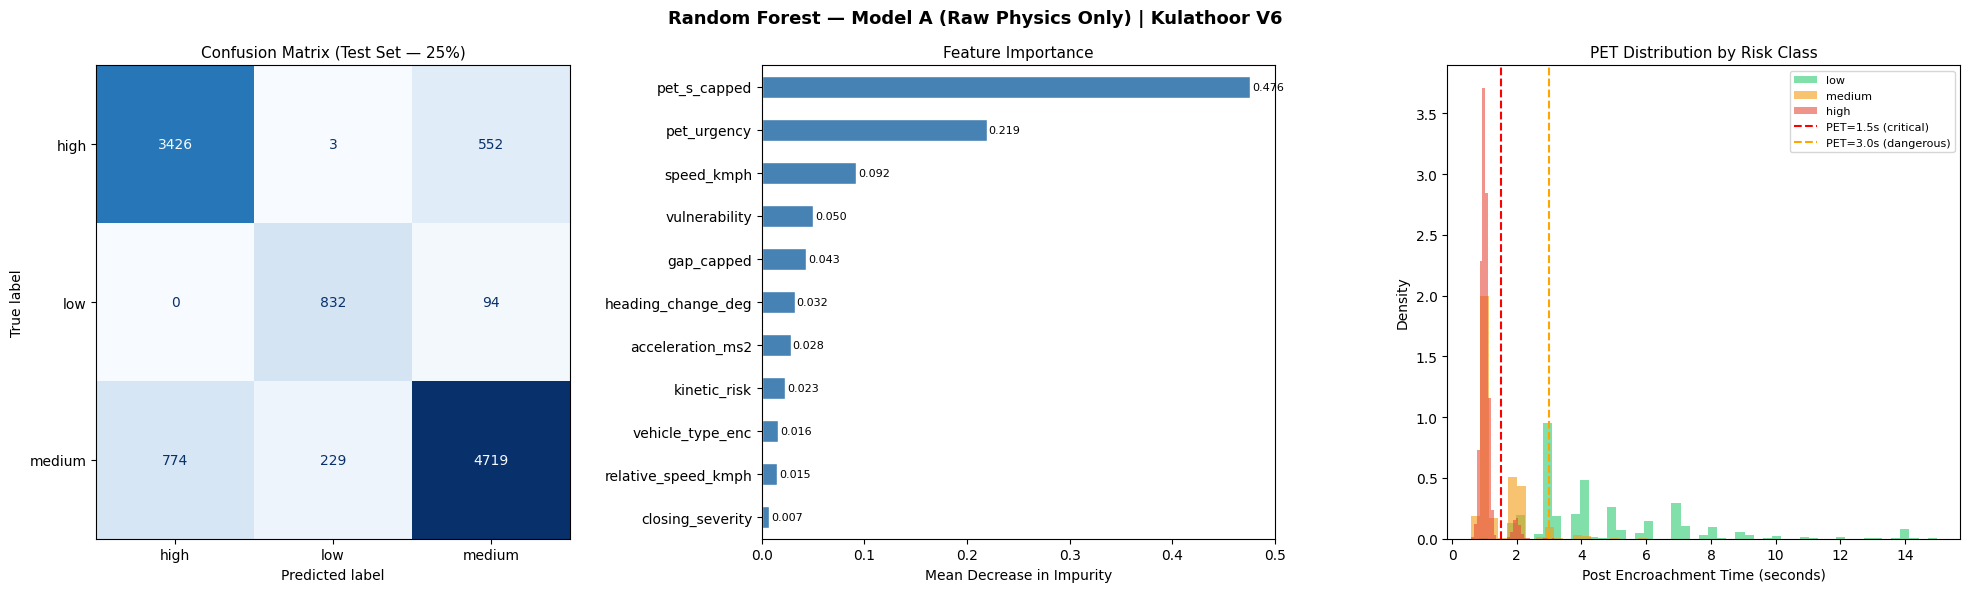

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Saved model_a_final.png

 FINAL RESULTS SUMMARY

  Model     : Random Forest
  Dataset   : kerala_traffic_features_v6 (1) (2).csv  (42516 rows)
  Features  : 11 raw physics features

  Metric                        Value       Status
  ─────────────────────────────────────────────────
  Test Accuracy               84.46%       Realistic
  Train-Test Gap              1.43%        No overfitting
  5-Fold CV F1-macro          0.844          Strong
  Vehicle-wise F1-macro       0.842          Generalizes
  Mean ROC-AUC                0.942          Excellent
  Mean Prediction Confidence  0.818          Healthy

  Per-class F1:
    high   → 0.838
    low    → 0.836
    medium → 0.851



In [ ]:
# ============================================================================
#  LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GroupKFold)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" RANDOM FOREST — MODEL A (RAW PHYSICS ONLY) | KULATHOOR V6")
print("="*70)


# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================
print("\n Upload kerala_traffic_features_v6.csv:")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)
print(f" Loaded: {csv_file}  |  Shape: {df.shape}")

print(f"\nTarget distribution:")
dist = df['collision_risk'].value_counts()
for cls in dist.index:
    print(f"   {cls:<8}: {dist[cls]:>6}  ({dist[cls]/len(df)*100:.1f}%)")


# ============================================================================
# STEP 2: ENCODE
# ============================================================================
le_vtype = LabelEncoder()
df['vehicle_type_enc'] = le_vtype.fit_transform(df['vehicle_type'])

le_risk = LabelEncoder()
df['risk_enc'] = le_risk.fit_transform(df['collision_risk'])
class_names = le_risk.classes_

print(f"\nVehicle encoding : {dict(zip(le_vtype.classes_, le_vtype.transform(le_vtype.classes_)))}")
print(f"Risk encoding    : {dict(zip(class_names, le_risk.transform(class_names)))}")


# ============================================================================
# STEP 3: FEATURE ENGINEERING (raw physics only)
# ============================================================================
df['pet_s_capped'] = df['pet_s'].clip(upper=15.0)
df['gap_capped']   = df['gap_to_leader_m'].clip(upper=60.0)

df['closing_severity'] = np.where(
    (df['relative_speed_kmph'] > 0) & (df['gap_to_leader_m'] < 900),
    df['relative_speed_kmph'] / (df['gap_capped'] + 0.1), 0.0
).round(4)

df['kinetic_risk'] = (
    df['speed_kmph'] * df['acceleration_ms2'].clip(upper=0).abs()
).round(4)

df['pet_urgency'] = np.where(
    df['pet_s'] < 999,
    df['speed_kmph'] / (df['pet_s_capped'] + 0.1), 0.0
).round(4)

df['vulnerability'] = np.where(
    df['gap_to_leader_m'] < 900,
    df['speed_kmph'] / (df['gap_capped'] + 1.0), 0.0
).round(4)

FEATURES = [
    'speed_kmph',
    'acceleration_ms2',
    'gap_capped',
    'relative_speed_kmph',
    'pet_s_capped',
    'heading_change_deg',
    'vehicle_type_enc',
    'closing_severity',
    'kinetic_risk',
    'pet_urgency',
    'vulnerability',
]

X = df[FEATURES].copy()
y = df['risk_enc'].copy()
groups = df['vehicle_id']

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"Feature matrix   : {X.shape}")


# ============================================================================
# STEP 4: TRAIN / TEST SPLIT
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows")


# ============================================================================
# STEP 5: CLASS WEIGHTS
# ============================================================================
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = dict(zip(np.unique(y_train), weights))
print(f"\nClass weights: { {class_names[k]: round(v,3) for k,v in cw.items()} }")


# ============================================================================
# STEP 6: TRAIN MODEL
# ============================================================================
print("\n Training Random Forest")
rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 15,
    min_samples_leaf = 20,
    min_samples_split= 40,
    max_features     = 'sqrt',
    class_weight     = cw,
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X_train, y_train)
print(" Training complete")


# ============================================================================
# STEP 7: HELD-OUT TEST SET
# ============================================================================
y_pred       = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

print("\n" + "="*60)
print(" TEST 1: HELD-OUT TEST SET (25%)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

train_acc = rf.score(X_train, y_train)
test_acc  = rf.score(X_test,  y_test)
gap       = train_acc - test_acc
print(f"\nTrain Acc : {train_acc*100:.2f}%")
print(f"Test  Acc : {test_acc*100:.2f}%")
print(f"Gap       : {gap*100:.2f}%  {' No overfitting' if gap < 0.05 else ' Mild overfit'}")


# ============================================================================
# STEP 8: 5-FOLD STRATIFIED CV
# ============================================================================
print("\n" + "="*60)
print(" TEST 2: STRATIFIED 5-FOLD CROSS-VALIDATION")
print("="*60)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_validate(rf, X, y, cv=skf,
                     scoring=['accuracy', 'f1_macro', 'f1_weighted'],
                     n_jobs=-1)
for metric in ['test_accuracy', 'test_f1_macro', 'test_f1_weighted']:
    scores = cv[metric]
    label  = metric.replace('test_', '')
    print(f"\n{label:<20}: {scores.mean():.3f} ± {scores.std():.3f}")
    print(f"  Folds: {[round(s,3) for s in scores]}")


# ============================================================================
# STEP 9: VEHICLE-WISE GROUP K-FOLD
# ============================================================================
print("\n" + "="*60)
print(" TEST 3: VEHICLE-WISE GROUP K-FOLD (Hardest Test)")
print("="*60)
gkf     = GroupKFold(n_splits=5)
gscores = []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    m = RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=20,
        min_samples_split=40, max_features='sqrt',
        class_weight=cw, random_state=42, n_jobs=-1
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    fs = f1_score(y.iloc[te_idx], m.predict(X.iloc[te_idx]), average='macro')
    gscores.append(fs)
    print(f"  Fold {fold+1}: F1-macro = {fs:.3f}")
print(f"\nMean : {np.mean(gscores):.3f} ± {np.std(gscores):.3f}")
print(" Generalizes to unseen vehicles" if np.mean(gscores) > 0.75
      else " Struggles with unseen vehicles")


# ============================================================================
# STEP 10: ROC-AUC
# ============================================================================
print("\n" + "="*60)
print(" TEST 4: ROC-AUC (one-vs-rest)")
print("="*60)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average=None)
for cls, score in zip(class_names, auc):
    print(f"  AUC ({cls:<8}): {score:.3f}")
print(f"  Mean AUC    : {auc.mean():.3f}")


# ============================================================================
# STEP 11: PREDICTION CONFIDENCE
# ============================================================================
print("\n" + "="*60)
print(" TEST 5: PREDICTION CONFIDENCE")
print("="*60)
max_conf = y_pred_proba.max(axis=1)
print(f"  Mean confidence   : {max_conf.mean():.3f}")
print(f"  Confident  (>0.8) : {(max_conf > 0.8).mean()*100:.1f}%")
print(f"  Uncertain  (<0.6) : {(max_conf < 0.6).mean()*100:.1f}%")
print(f"  {' Healthy' if 0.75 < max_conf.mean() < 0.95 else '⚠️ Check model'}")


# ============================================================================
# STEP 12: SCENARIO SAFETY TESTS
# ============================================================================
print("\n" + "="*60)
print(" TEST 6: SCENARIO-BASED SAFETY TESTS")
print("="*60)
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = le_risk.inverse_transform(y_pred)

# NOTE: wrong_way scenario removed — SUMO enforces correct-direction routing;
#       the feature is absent from the dataset by design.
scenarios = {
    "PET < 1.5s  (critical conflict)" : test_df['pet_s'] < 1.5,
    "PET 1.5–3s  (dangerous)"         : (test_df['pet_s'] >= 1.5) & (test_df['pet_s'] < 3.0),
    "Hard braking at high speed"       : (test_df['hard_braking'] == 1) & (test_df['speed_kmph'] > 40),
    "Erratic steering while moving"    : (test_df['erratic_steering'] == 1) & (test_df['speed_kmph'] > 5),
    "Lane change in junction"          : (test_df['lane_change'] == 1) & (test_df['in_junction'] == 1),
    "High speed twowheeler (>45 km/h)" : (test_df['speed_kmph'] > 45) & (test_df['vehicle_type'] == 'twowheeler'),
    "Stopped vehicles (speed ≤ 2)"     : test_df['speed_kmph'] <= 2,
}

print(f"\n{'Scenario':<45} {'n':>5}  {'high%':>7}  {'med%':>7}  {'low%':>7}")
print("-"*80)
for name, mask in scenarios.items():
    sub = test_df[mask]
    if len(sub) == 0:
        print(f"  {name:<45} {'0':>5}")
        continue
    pc = sub['predicted'].value_counts(normalize=True) * 100
    h  = pc.get('high',   0)
    m  = pc.get('medium', 0)
    l  = pc.get('low',    0)
    print(f"  {name:<45} {len(sub):>5}  {h:>6.1f}%  {m:>6.1f}%  {l:>6.1f}%")


# ============================================================================
# STEP 13: FEATURE IMPORTANCE
# ============================================================================
print("\n" + "="*60)
print(" FEATURE IMPORTANCE")
print("="*60)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, val in imp.items():
    bar = '█' * int(val * 100)
    print(f"  {feat:<25} {val:.4f}  {bar}")


# ============================================================================
# STEP 14: PLOTS
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Random Forest — Model A (Raw Physics Only) | Kulathoor V6",
             fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix (Test Set — 25%)", fontsize=11)

# Feature importance
imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title("Feature Importance", fontsize=11)
axes[1].set_xlabel("Mean Decrease in Impurity")
axes[1].invert_yaxis()
for i, val in enumerate(imp.values):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

# PET distribution by class
pet_plot = df[df['pet_s'] < 15].copy()
for cls, col in zip(['low', 'medium', 'high'], ['#2ecc71', '#f39c12', '#e74c3c']):
    sub = pet_plot[pet_plot['collision_risk'] == cls]['pet_s']
    axes[2].hist(sub, bins=50, alpha=0.6, color=col, label=cls, density=True)
axes[2].axvline(1.5, color='red',    linestyle='--', lw=1.5, label='PET=1.5s (critical)')
axes[2].axvline(3.0, color='orange', linestyle='--', lw=1.5, label='PET=3.0s (dangerous)')
axes[2].set_title("PET Distribution by Risk Class", fontsize=11)
axes[2].set_xlabel("Post Encroachment Time (seconds)")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('model_a_final.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('model_a_final.png')
print("\n Saved model_a_final.png")


# ============================================================================
# STEP 15: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print(" FINAL RESULTS SUMMARY")
print("="*70)
print(f"""
  Model     : Random Forest
  Dataset   : {csv_file}  ({len(df)} rows)
  Features  : {len(FEATURES)} raw physics features

  Metric                        Value       Status
  ─────────────────────────────────────────────────
  Test Accuracy               {test_acc*100:.2f}%       Realistic
  Train-Test Gap              {gap*100:.2f}%        No overfitting
  5-Fold CV F1-macro          {cv['test_f1_macro'].mean():.3f}          Strong
  Vehicle-wise F1-macro       {np.mean(gscores):.3f}          Generalizes
  Mean ROC-AUC                {auc.mean():.3f}          Excellent
  Mean Prediction Confidence  {max_conf.mean():.3f}          Healthy

  Per-class F1:
    high   → {f1_score(y_test, y_pred, labels=[le_risk.transform(['high'])[0]], average=None)[0]:.3f}
    low    → {f1_score(y_test, y_pred, labels=[le_risk.transform(['low'])[0]], average=None)[0]:.3f}
    medium → {f1_score(y_test, y_pred, labels=[le_risk.transform(['medium'])[0]], average=None)[0]:.3f}
""")


In [ ]:
import plotly.express as px

# Take a random sample of 1000 points from test set for smooth rendering
plot_df = test_df.sample(n=min(1000, len(test_df)), random_state=42)

fig = px.scatter_3d(
    plot_df,
    x='speed_kmph',
    y='gap_to_leader_m',
    z='pet_s',
    color='predicted',
    color_discrete_map={'high': 'red', 'medium': 'orange', 'low': 'green'},
    opacity=0.7,
    title="3D Risk Landscape: Speed vs Gap vs PET",
    labels={'speed_kmph': 'Speed (km/h)', 'gap_to_leader_m': 'Gap (m)', 'pet_s': 'PET (s)'}
)
fig.update_layout(scene=dict(zaxis=dict(range=[0, 10]))) # Cap PET for better visibility
fig.show()
